# AP 155 Lab Exercise
---
## Exercise 1: Idiomatic Python

_Instructions_: 
- **Report figure (Problem 1):** Plot the 2D wave interference pattern between 2 (or more) coherent sources. Include at least 1 figure.
- **Report discussion (Problem 2):** Write a custom `matrix_multiply()`function using Python list comprehensions without external libraries (do not use `np.dot()` or `@`).
    - (i) For larger matrices, which is preferred, the custom `matrix_multiply()` or the `@` operator... why?
    - (ii) What are the general benefits of writing idiomatic Python?
- **Code**: Complete the codes and ensure they are functional, error-free, readable, and efficient (where needed). Include a concise markdown documentation highlighting the critical steps of your algorithm for each problem.

### Student Information
- _Full Name (Last Name, First Name)_: Pasion, Kyla Zarina
- _Student No._: 2024-09224
- _Section_: WX-1

### Grading Information (c/o Lab Instructor)
- [Rubrics description link](https://drive.google.com/file/d/1G9tPPcyMUag91g_R02O0wsGYPiZWy5Nn/view?usp=drive_link) (Note: percentages may still be tweaked)

| Criteria | Score | Subtotal |
| --- | --- | --- |
| Report figure | XX | 20 |
| Report discussion | XX | 20|
| Code readability | XX | 20 |
| Code efficiency | XX | 20 | 
| Code appropriateness  | XX | 20 | 
| **TOTAL** | XXX | 100 |

_Date and Time Scored (MM/DD/YYYY HH:MM AM/PM):_:_

---
## Section 1: Report

### Problem 1: 2D Wave Interference (Gezerlis Problem 1.15)

![Figure for the Interference plot of Problem 1](./Figures/Interference.png)

**Figure 1.** The 2D wave interference pattern produced by two droplets acting as point sources located at $(\pm 1, 0)$ and $(0, \pm 1)$. The alternating regions of constructive and destructive interference form the visible wave pattern, with constructive interference occurring where the waves reinforce each other and destructive interference occurring where they cancel.

### Problem 2: Listcomps-maxxing

A custom `matrix_multiply()` function was implemented using Python list comprehensions without relying on external libraries for the actual multiplication. The function first checks whether the number of columns in the left matrix matches the number of rows in the right matrix. The right matrix is then transposed so that its columns can be accessed as rows, allowing the previously defined `scalar_product()` function to calculate each element of the product matrix.

1. **For larger matrices, which is preferred, the custom `matrix_multiply()` or the `@` operator, and why?**
   - Based on my experience, the `@` operator is much more efficient, especially for larger matrices, because it uses optimized numerical routines and is therefore faster and more efficient than a Python-level implementation using loops and list comprehensions. However, this exercise was more useful for understanding how matrix multiplication works internally.

2. **What are the general benefits of writing idiomatic Python?**
   - Writing idiomatic Python makes code more readable, concise, maintainable, and consistent with common Python practices. It can also reduce unnecessary complexity while making the programmer's intent easier to understand.

### Other comments

Before this exercise, I only knew basic Python operations, such as `@` and other NumPy operations. I accepted these operations as they were because they made my coding more efficient and easier. However, after this activity, I learned the importance of understanding how these operations work and of creating custom implementations. This exercise improved my Python coding skills and logical thinking by allowing me to understand the processes behind operations that I previously relied on without fully understanding them.


---
## Section 2: Code

### Problem 1: 2D Wave interference (Gezerlis Problem 1.15)

Assume that the combined eﬀect of two objects dropped in a water basin can be modelled by:
$$ W(\textbf{r}) = A \sin (k|\textbf{r}-\textbf{r}_0|) + A  \sin (k|\textbf{r}-\textbf{r}_1|). $$ You can think of this as an updated version of Eq. (1.3) in the book, where we are dealing with the linear addition of sinusoidal waves, instead of electric-field contributions. For simplicity, take $A=1$, $k=2\pi/0.3$, $r_0 = (−1, 0)$ , and $r_1 = (1, 0)$. Since we are now faced with a density plot, you should employ, NOT `streamplot()` but, `imshow()` from `Matplotlib`; in each of $x$ and $y$ your plot should extend from $−4$ to $+4$.

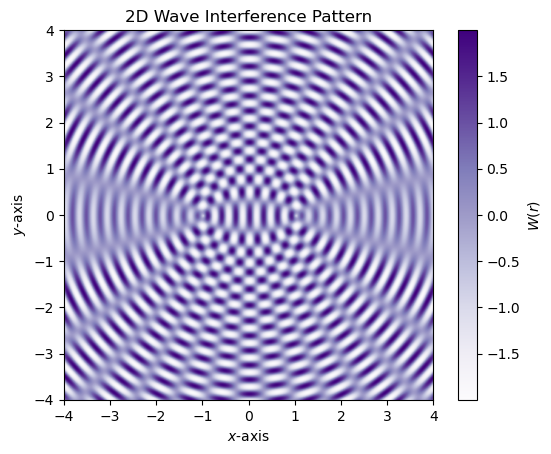

In [66]:
import matplotlib.pyplot as plt
import math as m

#--Constants-- 
A = 1 # Sets the amplitude A of each wave to 1
k = (2*m.pi)/0.3 # Calculates the wave number k = 2π/0.3


#--Modeling the water basin--
def W(xs, ys): # Defines a function that calculates W(r) at every point in the x-y grid.
    r = [(-1,0), (1,0)] # Stores the coordinates of the two wave sources
    n = len(xs) 
    Wr = [[0. for i in range(n)] for j in range(n)]  # Creates an n×n matrix filled with 0s to store W(r) values.

    # Loops through all the elements of the matrix
    for i,x in enumerate(xs): 
        for j,y in enumerate(ys):
            for rx, ry in r:
                R = m.sqrt((x-rx)**2 + (y-ry)**2) # Calculates the distance R between the two wave source (rx, ry) and grid point (x, y).
                Wr[j][i] += A * m.sin(k*R) # Adds the wave contribution A sin(kR) from the current source to W(r) at that grid point.

    return Wr

#--Creating the plot---
def plotfield(box,n):

     # Generate a list of n evenly spaced x-points spanning -box to +box to compute W(r)
    xs = [-box + i*2*box/(n--1) for i in range(n)]
    ys = xs[:]
    Wr = W(xs,ys)

    plt.title('2D Wave Interference Pattern')
    plt.imshow(Wr, extent=(-box, box, -box, box), cmap='Purples')
    plt.colorbar(label='$W(r)$')
    plt.xlabel('$x$-axis')
    plt.ylabel('$y$-axis')
    plt.show()
    
fig = plotfield(4, 500)

#### Problem 1 code summary

This code models the interference pattern produced by two waves in a water basin by calculating the distance from every point in the basin to each wave source and adding their sinusoidal contributions. Loops were used to make it easier to calculate the values at each coordinate and visualize the step-by-step process. A 2D matrix is used to store the resulting $W(r)$ values so that `imshow()` can display them as a density plot, allowing the overall interference pattern to be visualized clearly.

---

### Problem 2: Listcomps-maxxing

Import the `random` library (docs: https://docs.python.org/3/library/random.html). We will be using the `random.randint` function to pick random integers.

In [15]:
import random
number = random.randint(1, 9)
number

9

a. Create a function `random_integer_matrix(nrows, ncols)` that generates a matrix in the form of "list-of-lists" whose elements are random integers from $1$ to $9$. Each "sub-list" inside the main list is a row in the matrix.

In [55]:
def random_integer_matrix(nrows, ncols): # Defines a function that creates a matrix with nrows rows and ncols columns.   
    M = [[0 for i in range(ncols)] for y in range(nrows)] # Creates an nrows × ncols matrix filled with zeros as a placeholder.
    for i in range(nrows): 
        for j in range(ncols): 
            M[i][j] = random.randint(1,9) # Generates a random integer from 1 to 9 and assigns it to the element at row i, column j.
    return M 

list_1 = random_integer_matrix(3,4) # Calls the function to create a 3×4 matrix.
list_2 = random_integer_matrix(3,4) 
print(list_1, ",\n", list_2)

[[5, 2, 5, 8], [6, 8, 9, 4], [6, 6, 9, 5]] ,
 [[2, 5, 4, 8], [9, 3, 2, 4], [8, 7, 3, 9]]


b. Create a function `scalar_product(list1, list2)` where you multiply each element at the same index in the two lists and sum/accumulate the results.

In [56]:
def random_vector(n):
    V = [0 for i in range(n)] # Creates a vector of length n filled with zeros as placeholders.
    for i in range(n):
        V[i] = random.randint(1,9) # Generates a random integer from 1 to 9 and assigns it to the element at index i.
    return V

# Creates a vector with 4 elements
vec_1 = random_vector(4) 
vec_2 = random_vector(4)

print(vec_1, ",\n", vec_2)

# Checks whether two vectors have the same dimension.
def check_dim(vec_1, vec_2): 
    if len(vec_1) != len(vec_2): 
        print("Invalid input. Must be same in dimension")
        return False
    return True

def scalar_product(vec_1, vec_2): 
    if check_dim(vec_1, vec_2):
        product = 0
        for i in range(len(vec_1)): 
            product += vec_1[i] * vec_2[i] # Multiplies corresponding elements and adds the results to product.
    return product

print(f"Scalar Product: {scalar_product(vec_1,vec_2)}")

[7, 3, 4, 9] ,
 [5, 4, 2, 4]
Scalar Product: 91


In [28]:
# use as many cell blocks as you want (as long as they all are functional)
# include valuable comments (even for trivial functions, a one-liner will do)

c. Create a function `transpose_matrix(orig_matrix)` which returns the transpose of any matrix also in "list-of-lists" form. Do not assume the size of the matrix; figure it out within the function. Double-check that your implementations above work. Create a $3\times4$ random integer matrix, print it out and its transpose. The values and shape between the two should be consistent.

In [61]:
def transpose_matrix(orig_matrix):
    # The * unpacks the rows of the matrix so that zip() can group elements with the same column position.
    # Each resulting tuple is then converted into a list to create the transposed matrix.
    return [list(row) for row in zip(*orig_matrix)]

matrix = random_integer_matrix(3, 4) # Generates a 3x4 matrix filled with random integers from 1 to 9
transposed = transpose_matrix(matrix) 
print("Original matrix:") 
for row in matrix: # Loops through each row of the original matrix
    print(row) # Prints each row on a separate line 

print("Transposed matrix:") 
for row in transposed: 
    print(row) 

Original matrix:
[6, 5, 8, 6]
[2, 1, 3, 3]
[2, 6, 8, 2]
Transposed matrix:
[6, 2, 2]
[5, 1, 6]
[8, 3, 8]
[6, 3, 2]


d. Create a function `matrix_multiply(left_matrix, right_matrix)` which performs the matrix multiplication. Do not assume the matrices follow a specific shape. Here's some tips and strategies:
* Determine how many rows and columns the left and right matrices have. Which numbers should match in order for us to have valid matrix multiplication?
* Iterating the elements of "list-of-lists" gives us the rows, but we need to iterate the columns for the right matrix.
* Use the `transpose_matrix` function, then iteratively apply `scalar_product`.

In [65]:
import numpy as np

matrix_1 = random_integer_matrix(3,4)
matrix_2 = random_integer_matrix(4,3)

print("Matrix A:")
for row in matrix_1:
    print(row)

print("Matrix B:")
for row in matrix_2:
    print(row)

def matrix_multiply(A, B):
    if len(A[0]) != len(B): # In order for the multiplication to be valid, we check whether the number of columns in A is equal to the number of rows in B
        print("Product not defined. Invalid dimensions")
        return
    prod_rows = len(A)
    prod_columns = len(B[0])
    transposed_B = transpose_matrix(B) # Transposing matrix B to utilize the scalar_product function in order to easily compute the product
    product = [[scalar_product(A[y], transposed_B[x]) for x in range(prod_columns)] for y in range(prod_rows)] # Calculates each element of the product matrix by taking the scalar product of each row of A with each column of B.

    return product

print(f"matrix_multiply_func: {matrix_multiply(matrix_1, matrix_2)}") 
# Checking accuracy by comparing the answer with NumPy's built-in matrix multiplication
print(f"matrix_multiply_with@: {np.array(matrix_1) @ np.array(matrix_2)}")


Matrix A:
[9, 2, 8, 9]
[2, 6, 6, 5]
[3, 4, 5, 7]
Matrix B:
[8, 5, 9]
[3, 1, 5]
[6, 9, 7]
[3, 3, 9]
matrix_multiply_func: [[153, 146, 228], [85, 85, 135], [87, 85, 145]]
matrix_multiply_with@: [[153 146 228]
 [ 85  85 135]
 [ 87  85 145]]


#### Problem 2 code summary

A basic matrix operation algorithm was implemented using list-of-lists without relying on NumPy for the actual calculations. The matrices are built using zero-filled placeholders, while the scalar product, transposition, and matrix multiplication are calculated element-by-element. I chose to transpose the right matrix so I could reuse the scalar product function, as this was the most intuitive way for me to understand and implement matrix multiplication from scratch.

---
## Section 3: Background

### Basics

In [9]:
x = 0.5 # floats
y = 1 # integer
z = 'Hello' # string

x, y = y, x # swapping variables
a, b = 2, 3 # multiple assignments
print(x)
print(y)

1
0.5


In [10]:
x + y # sum
x - y # difference
x * y # multiplication
x / y # division
x // y # floor division
x % y # modulo
x ** y # power

1.0

### Control flow

In [11]:
x = 0

if x!= 0:
    print("x is nonzero")
elif x==0:
    print("x is zero")

x is zero


In [12]:
y = 25
if (y%5==0) == True:
    print('y is divisible by 5')

y is divisible by 5


In [13]:
# you can write truthiness conditionals more succinctly as 
# if condition is True, mathematically a True equals 1.0 while a False equals 0.0
if not (y%5):
    print('y is divisible by 5')

y is divisible by 5


In [14]:
for i in range(1,15,2):
    print(0.01*i, end=" ") # the end=" " syntax tells the value shall be printed in line

0.01 0.03 0.05 0.07 0.09 0.11 0.13 

### Data structures

In [15]:
xs = []
for i in range(20):
    xs.append(0.1*i)

# BE CAREFUL!!!
# list is different from array
list1 = [1, 2, 3]
list2 = [4, 5, 6]
list1 + list2 # concatenates

[1, 2, 3, 4, 5, 6]

In [16]:
list1 = np.array([1, 2, 3])
list2 = np.array([4, 5, 6])
list1 + list2 # adds element-wise!

array([5, 7, 9])

In [17]:
# Tuples are primarily used to bundle related pieces of data together, 
# protect data from accidental modification, and optimize performance.

tuple1 = (1, 2, 3)
tuple1[1]  # can be indexed just like lists

2

In [18]:
# strings can also be indexed like numbers

name = "Wilson"
name[0]

'W'

In [19]:
# string dot format arguments

x, y = 3.1, - 2.5
"{0:1.15f} {1:1.0f}".format(x, y) 

# the general string format looks like "{2} {0} {1}".format(a, b, c)
# the number inside the curly brackets contain the index of the variables inside the format( ... )
# you can modify the numbers outputted by specifiying the datatype inside the curly bracket 
# {0:1.15f} means print the zeroth number and print the number as a float with 15 decimal places 
# {1: 1.0f} means print the 1st number (second actually) and print as a float with 0 decimal places

'3.100000000000000 -2'

In [20]:
# slicing a list creates a new list

xs = [1, 2, 3]
ys = xs[1:] # the square bracket after a list corresponds to index (start:end) ... (start:end:interval)
zs = xs[:] # [:] means copy everything --> create an exact (shallow) copy of xs
print(xs)
print(ys)

# shallow copy duplicates an object's top-level properties 
# but keeps references to any nested objects, meaning changes to nested data affect the original. 
# A deep copy fully clones all levels and nested structures,
# creating a completely independent duplicate where changes do not affect the original.

[1, 2, 3]
[2, 3]


In [21]:
import copy
from copy import deepcopy

original = [1, 2, [3, 4]] # notice the list inside a list
shallow_copied = original[:]

# modifying a top-level element
shallow_copied[0] = 99
print("After modifying top-level element:")
print(f"Original: {original}")        
print(f"Copied:   {shallow_copied}")  

# modifying a nested mutable element
shallow_copied[2][0] = "changed" 
print("\nAfter modifying nested element (SHALLOW):") # BTW \n in string means paragraph break
print(f"Original: {original}")        
print(f"Copied:   {shallow_copied}")  

deep_copied = deepcopy(original)
original = [1, 2, [3, 4]]
deep_copied[2][0] = "changed" 
print("\nAfter modifying nested element (DEEP COPIED):") # BTW \n in string means paragraph break
print(f"Original: {original}")        
print(f"Copied:   {deep_copied}")  

After modifying top-level element:
Original: [1, 2, [3, 4]]
Copied:   [99, 2, [3, 4]]

After modifying nested element (SHALLOW):
Original: [1, 2, ['changed', 4]]
Copied:   [99, 2, ['changed', 4]]

After modifying nested element (DEEP COPIED):
Original: [1, 2, [3, 4]]
Copied:   [1, 2, ['changed', 4]]


In [22]:
# dictionaries

htow = {1.41: 31.3, 1.45: 36.7, 1.48: 42.4} # is a dictionary associating heights to weights
# each entry is separated by a comma,
# each entry is composed of keys and items
# the first key is 1.41 with corresponding 31.3 item

for key, item in htow.items():
    print(f'key is {key} with item {item}')

# dictionaries are pretty useful for collecting a parallel set of content
# you can use strings as keys too

key is 1.41 with item 31.3
key is 1.45 with item 36.7
key is 1.48 with item 42.4


### User-defined functions

In [23]:
# start with def<space>name_of_your_function(input, parameters):
# end with return
# once a function encounters return, it ends all operations and sends the value back to the caller

def sumofints(nmax):
    val = sum(range(1,nmax+1))
    return val

# use the above function as
x = sumofints(42)
print(x)

# you could have multiple inputs and outputs
# functions can also return multiple values (effectively the output is a tuple for such cases)

903


In [33]:
from math import cos

def cosder(x, h=0.01): # here h is a default parameter (meaning it already has a preset value)
    return (cos(x+h) - cos(x))/h

#You can call this function with either 
cosder(0.)
#or 
cosder(0., 0.001)
#ie the 2nd argument is optional

-0.0004999999583255033

In [25]:
# you can also pass functions as inputs
def der(f, x, h=0.01):
    return (f(x+h) - f(x))/h

### List comprehensions
"Using such alternative syntax to make the code more concise and ex-
pressive helps us write new programs, but also makes the lives of future readers easier. Of
course, you do have to exercise your judgement."

In [34]:
def f(x):
    return x//2

xs = [0.1*i for i in range(20)] 
ys = [2*x for x in xs] # multiplication operation with a list
ws = [f(x) for x in xs] # evaluating a function with elements of a list
zs = [2*x for x in xs if x>0.3] # pruning a list

### Basic plotting

- We will utilize NumPy and Matplotlib for most of our visualization
    - `import numpy as np` # Docs: https://numpy.org/doc/stable/reference/
    - `import matplotlib.pyplot as plt` # Docs: https://matplotlib.org/stable/api/pyplot_summary.html
  
- We will use Seaborn only to make the defaults look pretty.
- Our focus is to make plotting as flexible as possible.
- Check out its documentation if you're interested with its convenience features.
    - `import seaborn as sns` # Guide: https://seaborn.pydata.org/tutorial/introduction.html
    `sns.set_theme(style="darkgrid")`

<img src="figures/gezerlisTable1_1.png" width="67%">

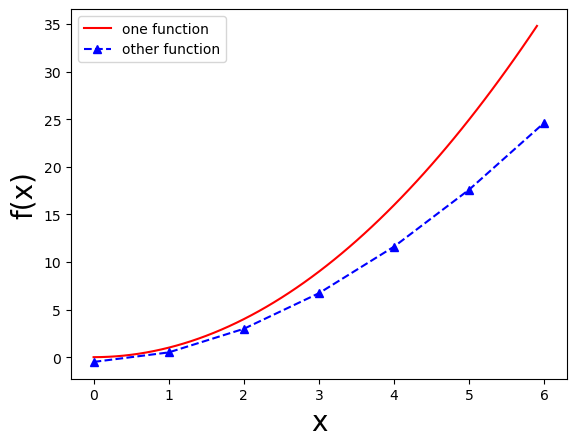

In [27]:
import matplotlib.pyplot as plt

def plotex(cxs,cys,dxs,dys):
    plt.xlabel('x', fontsize=20)
    plt.ylabel('f(x)', fontsize=20)
    plt.plot(cxs, cys, 'r-', label='one function')
    plt.plot(dxs, dys, 'b--^', label='other function')
    plt.legend()
    plt.show()

cxs = [0.1*i for i in range(60)]
cys = [x**2 for x in cxs]
dxs = [i for i in range(7)]
dys = [x**1.8 - 0.5 for x in dxs]

plotex(cxs, cys, dxs, dys)

<ErrorbarContainer object of 3 artists>

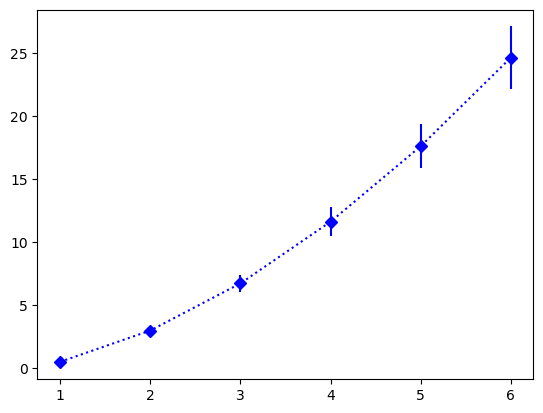

In [29]:
dyerrs = [0.1*y for y in dys]
plt.errorbar(dxs[1:], dys[1:], dyerrs[1:], fmt='b:D', label='with errors')

### NumPy idioms

<img src="figures/gezerlisTable1_2.png" width="67%">

In [30]:
import numpy as np

# for parallel computations: contribs = [w*f(x) for w,x in zip(ws,xs)]

zs = np.array([5, 8], dtype=np.float32) # converts contribs into a NumPy array
A, B, C = np.zeros(5), np.ones(4), np.arange(6)

print(A)
print(B)
print(C)

[0. 0. 0. 0. 0.]
[1. 1. 1. 1.]
[0 1 2 3 4 5]


In [31]:
# you can specify set of points

np.linspace(1, 10, 6) # 6 linearly spaced points from 1 to 10 (including 1 and 10)
np.arange(1, 10, 6) # from 1 to 10 in steps of 6
np.logspace(1, 10, 6) # 6 logarithmically spaced points from 1 to 10

# if you're not sure what to input, you can always shift+Tab inside the parenthesis to check the arguments

array([1.00000000e+01, 6.30957344e+02, 3.98107171e+04, 2.51188643e+06,
       1.58489319e+08, 1.00000000e+10])

<img src="figures/gezerlisTable1_3.png" width="67%">

<img src="figures/gezerlis_slicingArrays.png" width="67%">

### Visualizing Electric Fields 

The electric field anywhere given a set of $n$ point charges is given by
$$ \mathbf{E}(\mathbf{r}) = \sum_{i=0}^{n-1} kq_i \frac{\mathbf{r} - \mathbf{r}_i}{|\mathbf{r} - \mathbf{r}_i|^3} $$

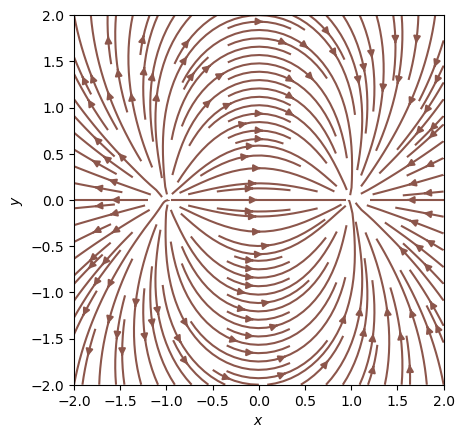

In [43]:
import numpy as np
import matplotlib.pyplot as plt
from math import sqrt
from copy import deepcopy

def makefield(xs, ys):
    qtopos = {1: (-1,0), -1: (1,0)}
    n = len(xs)
    Exs = [[0. for k in range(n)] for j in range(n)]
    Eys = deepcopy(Exs)
    for j,x in enumerate(xs):
        for k,y in enumerate(ys):
            for q, pos in qtopos.items():
                posx, posy  = pos
                R = sqrt((x - posx)**2 + (y - posy)**2)
                Exs[k][j] += q*(x - posx)/R**3
                Eys[k][j] += q*(y - posy)/R**3
    return Exs, Eys

def plotfield(boxl,n):
    xs = [-boxl + i*2*boxl/(n-1) for i in range(n)]
    ys = xs[:]
    Exs, Eys = makefield(xs, ys)
    xs=np.array(xs); ys=np.array(ys)
    Exs=np.array(Exs); Eys=np.array(Eys)
    plt.streamplot(xs, ys, Exs, Eys, density=1.5, color='tab:brown')
    plt.xlabel('$x$')
    plt.ylabel('$y$')
    plt.axis('square')
    plt.show()
    
plotfield(2., 50)

In [48]:
# sample plotting in notebook and putting saved image in another cell (see Report figure)

import matplotlib.pyplot as plt
import numpy as np

# sample grid and data
x = np.linspace(-5, 5, 100)
y = np.linspace(-5, 5, 100)
X, Y = np.meshgrid(x, y)
Z1 = np.sin(np.sqrt(X**2 + Y**2))        

# create subplots
fig, axs = plt.subplots(1, 2, figsize=(10, 4))

# plot on first axs (left)
axs[0].imshow(Z1, cmap='viridis')
axs[0].set_title("Subtitle 1")
axs[0].axis('off')

# plot on the second axis (right)
axs[1].imshow(Z1, cmap='plasma')
axs[1].set_title("Subtitle 2")
axs[1].axis('off')

fig.suptitle("Super title")

# save image locally without rendering in the notebook
plt.savefig('figures/sample.png', bbox_inches='tight', dpi=150)
plt.close()